# Análisis predictivo del aterrizaje (clasificación)
Se comparan Regresión Logística, SVM, Árbol de Decisión y KNN con `GridSearchCV`; se evalúan con exactitud y matriz de confusión.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
def plot_cm(y,yp,t):
    cm=confusion_matrix(y,yp);ax=plt.subplot();sns.heatmap(cm,annot=True,ax=ax,fmt='d')
    ax.set_xlabel('Predicho');ax.set_ylabel('Real');ax.set_title(t)
    ax.xaxis.set_ticklabels(['No aterrizó','Aterrizó']);ax.yaxis.set_ticklabels(['No aterrizó','Aterrizó']);plt.show()
def load(n):
    try:return pd.read_csv(n)
    except FileNotFoundError:return pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/'+n)
data=load('dataset_part_2.csv');X=load('dataset_part_3.csv')
Y=data['Class'].to_numpy()

In [2]:
X=preprocessing.StandardScaler().fit(X).transform(X)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)
print(X_test.shape)

(18, 80)


{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'} 0.8214285714285714 test: 0.8333333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

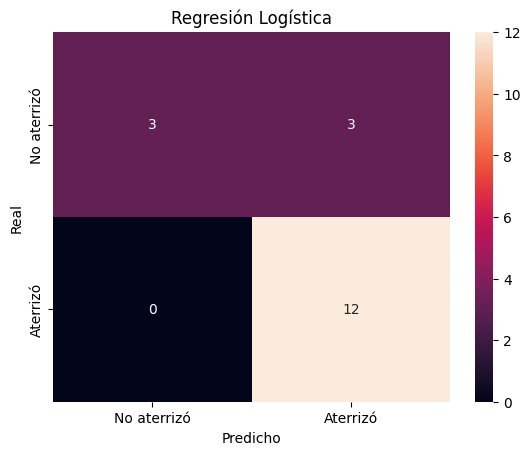

In [3]:
params={'C':[0.01,0.1,1],'penalty':['l2'],'solver':['lbfgs']}
logreg_cv=GridSearchCV(LogisticRegression(),params,cv=10).fit(X_train,Y_train)
print(logreg_cv.best_params_,logreg_cv.best_score_,'test:',logreg_cv.score(X_test,Y_test))
plot_cm(Y_test,logreg_cv.predict(X_test),'Regresión Logística')

{'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'} 0.8482142857142858 test: 0.8333333333333334


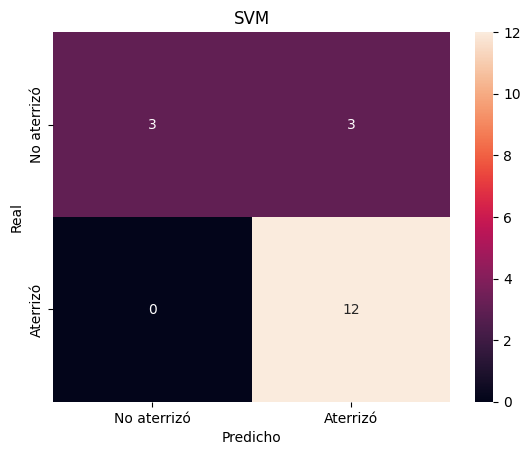

In [4]:
params={'kernel':('linear','rbf','poly','sigmoid'),'C':np.logspace(-3,3,5),'gamma':np.logspace(-3,3,5)}
svm_cv=GridSearchCV(SVC(),params,cv=10).fit(X_train,Y_train)
print(svm_cv.best_params_,svm_cv.best_score_,'test:',svm_cv.score(X_test,Y_test))
plot_cm(Y_test,svm_cv.predict(X_test),'SVM')

{'criterion': 'gini', 'max_depth': 2, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'} 0.8589285714285714 test: 0.8888888888888888


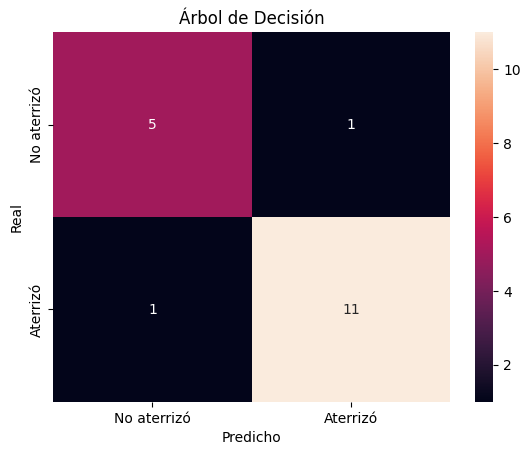

In [5]:
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':[2*n for n in range(1,10)],
'max_features':['sqrt','log2'],'min_samples_leaf':[1,2,4],'min_samples_split':[2,5,10]}
tree_cv=GridSearchCV(DecisionTreeClassifier(random_state=1),params,cv=10).fit(X_train,Y_train)
print(tree_cv.best_params_,tree_cv.best_score_,'test:',tree_cv.score(X_test,Y_test))
plot_cm(Y_test,tree_cv.predict(X_test),'Árbol de Decisión')

{'algorithm': 'auto', 'n_neighbors': 6, 'p': 1} 0.8339285714285714 test: 0.8333333333333334


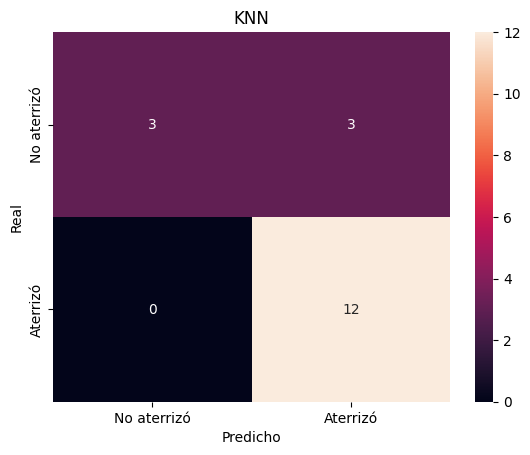

In [6]:
params={'n_neighbors':list(range(1,11)),'algorithm':['auto','ball_tree','kd_tree','brute'],'p':[1,2]}
knn_cv=GridSearchCV(KNeighborsClassifier(),params,cv=10).fit(X_train,Y_train)
print(knn_cv.best_params_,knn_cv.best_score_,'test:',knn_cv.score(X_test,Y_test))
plot_cm(Y_test,knn_cv.predict(X_test),'KNN')

                Modelo  CV (mejor)    Prueba
0  Regresión Logística    0.821429  0.833333
1                  SVM    0.848214  0.833333
2    Árbol de Decisión    0.858929  0.888889
3                  KNN    0.833929  0.833333


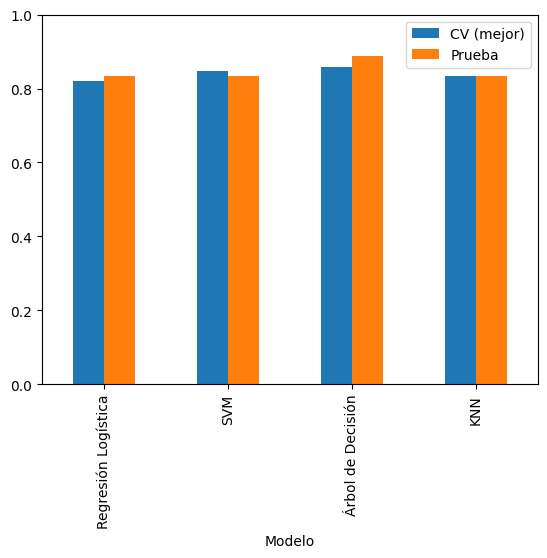

Mejor modelo en validación cruzada: Árbol de Decisión


In [7]:
res=pd.DataFrame({'Modelo':['Regresión Logística','SVM','Árbol de Decisión','KNN'],
'CV (mejor)':[m.best_score_ for m in (logreg_cv,svm_cv,tree_cv,knn_cv)],
'Prueba':[m.score(X_test,Y_test) for m in (logreg_cv,svm_cv,tree_cv,knn_cv)]})
print(res);res.set_index('Modelo').plot.bar();plt.ylim(0,1);plt.show()
print('Mejor modelo en validación cruzada:',res.loc[res['CV (mejor)'].idxmax(),'Modelo'])

## Conclusiones
- El mejor modelo se elige por la exactitud en validación cruzada; con un conjunto de prueba de solo 18 registros, varios modelos empatan.
- El error principal son los falsos positivos (predice aterrizaje cuando falló).
- Ideas: añadir clima y viento, probar Random Forest/XGBoost y calibrar probabilidades para estimar costos.